# Bootstrap

Bootstrap estimates the sampling distribution of any statistical functional by repeatedly resampling from the data.

**Two resampling strategies:**
- `ClassicalResampling` — samples with replacement from the original data (discrete empirical distribution)
- `SmoothResampling` — samples from a KDE-fitted continuous approximation (`EmpiricalDistribution`)

**Workflow:** `Bootstrap(data).run(functional)` → `BootstrapResult` with `.confidence_interval()`, `.standard_error()`, `.bias()`

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pysatl_core.distributions.empirical import EmpiricalDistribution, ScipyGaussianKde
from pysatl_core.inference import Bootstrap, ClassicalResampling, SmoothResampling

## 1. Data

A bimodal mixture of two Gaussians — a realistic case where the distribution is not symmetric.

n = 1000,  mean = 1.470,  std = 2.542


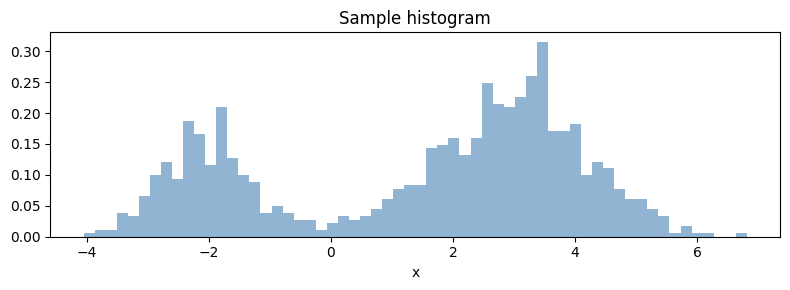

In [2]:
rng = np.random.default_rng(42)

data = np.concatenate([
    rng.normal(loc=-2.0, scale=0.8, size=300),
    rng.normal(loc=3.0,  scale=1.2, size=700),
])

print(f"n = {len(data)},  mean = {data.mean():.3f},  std = {data.std():.3f}")

plt.figure(figsize=(8, 3))
plt.hist(data, bins=60, density=True, color="steelblue", alpha=0.6)
plt.title("Sample histogram")
plt.xlabel("x")
plt.tight_layout()
plt.show()

## 2. Classical bootstrap — confidence interval for the mean

`Bootstrap(data, rng=rng).run(np.mean)` runs B resamples and returns a `BootstrapResult`.

In [3]:
result = Bootstrap(data, B=5000, rng=np.random.default_rng(0)).run(np.mean)

lo, hi = result.confidence_interval(level=0.95)

print(f"observed mean : {result.observed:.4f}")
print(f"standard error: {result.standard_error():.4f}")
print(f"bias          : {result.bias():.4f}")
print(f"95% CI        : [{lo:.4f}, {hi:.4f}]")

observed mean : 1.4703
standard error: 0.0794
bias          : 0.0000
95% CI        : [1.3136, 1.6284]


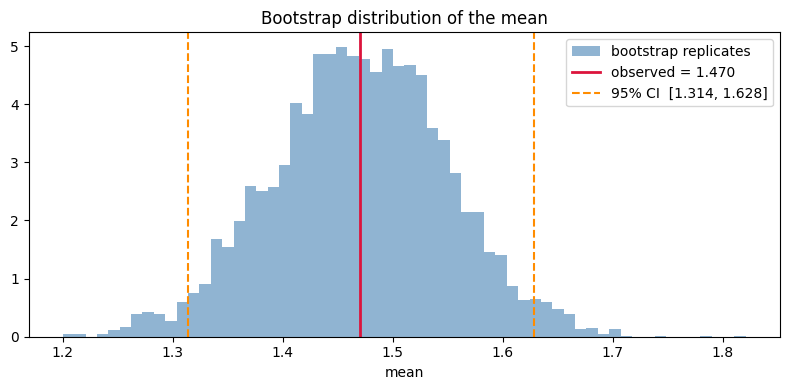

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(result.replicates, bins=60, density=True, color="steelblue", alpha=0.6, label="bootstrap replicates")
ax.axvline(result.observed, color="crimson",   lw=2, label=f"observed = {result.observed:.3f}")
ax.axvline(lo,              color="darkorange", lw=1.5, ls="--", label=f"95% CI  [{lo:.3f}, {hi:.3f}]")
ax.axvline(hi,              color="darkorange", lw=1.5, ls="--")
ax.set_title("Bootstrap distribution of the mean")
ax.set_xlabel("mean")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Any statistical functional

`Bootstrap.run()` accepts any callable `(NDArray) → float`.  
Below: mean, std, median, and 90th percentile — all in one loop.

In [5]:
functionals = {
    "mean":    np.mean,
    "std":     np.std,
    "median":  np.median,
    "p90":     lambda x: float(np.percentile(x, 90)),
}

boot = Bootstrap(data, B=5000, rng=np.random.default_rng(1))

results = {name: boot.run(fn) for name, fn in functionals.items()}

print(f"{'functional':<10}  {'observed':>10}  {'se':>8}  {'bias':>8}  {'95% CI'}")
print("-" * 62)
for name, r in results.items():
    lo, hi = r.confidence_interval()
    print(f"{name:<10}  {r.observed:>10.4f}  {r.standard_error():>8.4f}  {r.bias():>8.4f}  [{lo:.4f}, {hi:.4f}]")

functional    observed        se      bias  95% CI
--------------------------------------------------------------
mean            1.4703    0.0793   -0.0012  [1.3096, 1.6229]
std             2.5416    0.0373   -0.0028  [2.4660, 2.6109]
median          2.3296    0.1023   -0.0032  [2.1204, 2.5126]
p90             4.2716    0.0881   -0.0204  [4.0748, 4.4090]


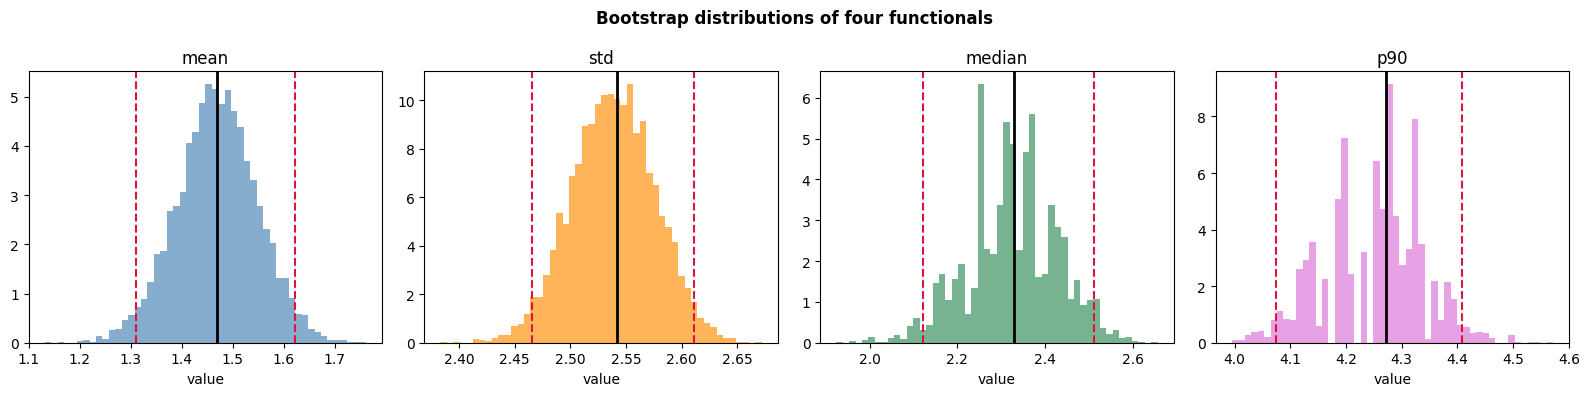

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Bootstrap distributions of four functionals", fontweight="bold")

colors = ["steelblue", "darkorange", "seagreen", "orchid"]

for ax, (name, r), color in zip(axes, results.items(), colors):
    lo, hi = r.confidence_interval()
    ax.hist(r.replicates, bins=50, density=True, color=color, alpha=0.65)
    ax.axvline(r.observed, color="black", lw=2)
    ax.axvline(lo, color="crimson", lw=1.5, ls="--")
    ax.axvline(hi, color="crimson", lw=1.5, ls="--")
    ax.set_title(name)
    ax.set_xlabel("value")

plt.tight_layout()
plt.show()

## 4. Smooth bootstrap via EmpiricalDistribution

`SmoothResampling` draws new samples from a KDE-fitted `EmpiricalDistribution` instead of the original data points.  
This means bootstrap replicates are never identical to any original value — the distribution of replicates is smoother.

The `EmpiricalDistribution` is fitted once and cached inside `SmoothResampling` across all B iterations.

In [7]:
result_classical = Bootstrap(data, B=3000, rng=np.random.default_rng(2)).run(np.mean)
result_smooth    = Bootstrap(data, B=3000, method=SmoothResampling()).run(np.mean)

for label, r in [("classical", result_classical), ("smooth", result_smooth)]:
    lo, hi = r.confidence_interval()
    print(f"{label:<10}  observed={r.observed:.4f}  se={r.standard_error():.4f}  95% CI=[{lo:.4f}, {hi:.4f}]")

classical   observed=1.4703  se=0.0798  95% CI=[1.3136, 1.6226]
smooth      observed=1.4703  se=0.0829  95% CI=[1.3100, 1.6373]


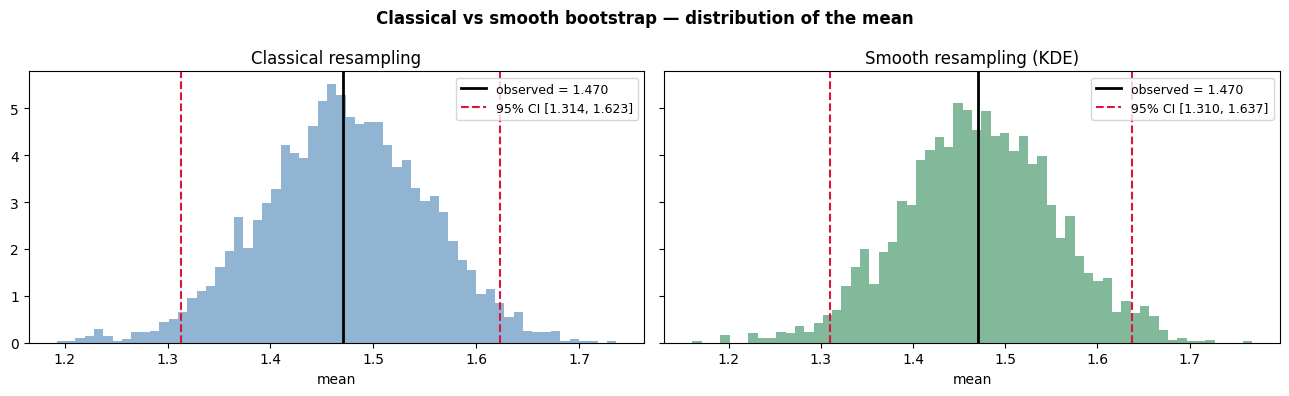

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
fig.suptitle("Classical vs smooth bootstrap — distribution of the mean", fontweight="bold")

for ax, (label, r, color) in zip(axes, [
    ("Classical resampling", result_classical, "steelblue"),
    ("Smooth resampling (KDE)", result_smooth, "seagreen"),
]):
    lo, hi = r.confidence_interval()
    ax.hist(r.replicates, bins=60, density=True, color=color, alpha=0.6)
    ax.axvline(r.observed, color="black",     lw=2,   label=f"observed = {r.observed:.3f}")
    ax.axvline(lo,          color="crimson",   lw=1.5, ls="--", label=f"95% CI [{lo:.3f}, {hi:.3f}]")
    ax.axvline(hi,          color="crimson",   lw=1.5, ls="--")
    ax.set_title(label)
    ax.set_xlabel("mean")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Smooth bootstrap with a custom KDE bandwidth

`SmoothResampling` accepts any `EmpiricalMethod`, so you can control the KDE bandwidth.  
A wider bandwidth → smoother resampling distribution; narrower → closer to classical.

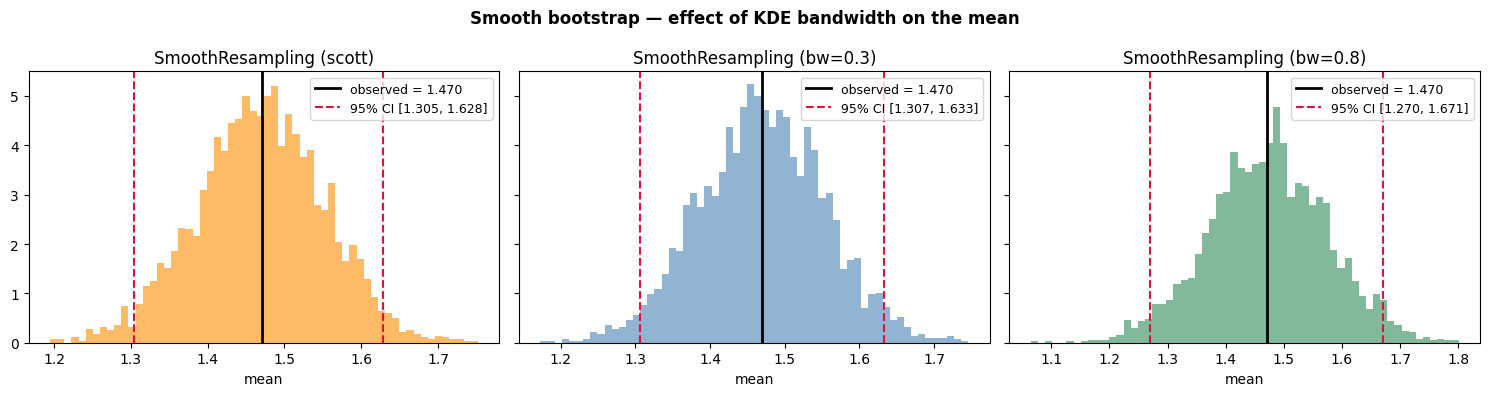

In [9]:
bandwidths = {"scott": "scott", "bw=0.3": 0.3, "bw=0.8": 0.8}

bw_results = {
    label: Bootstrap(data, B=3000, method=SmoothResampling(ScipyGaussianKde(bw))).run(np.mean)
    for label, bw in bandwidths.items()
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Smooth bootstrap — effect of KDE bandwidth on the mean", fontweight="bold")

colors = ["darkorange", "steelblue", "seagreen"]
for ax, (label, r), color in zip(axes, bw_results.items(), colors):
    lo, hi = r.confidence_interval()
    ax.hist(r.replicates, bins=60, density=True, color=color, alpha=0.6)
    ax.axvline(r.observed, color="black",   lw=2,   label=f"observed = {r.observed:.3f}")
    ax.axvline(lo,          color="crimson", lw=1.5, ls="--", label=f"95% CI [{lo:.3f}, {hi:.3f}]")
    ax.axvline(hi,          color="crimson", lw=1.5, ls="--")
    ax.set_title(f"SmoothResampling ({label})")
    ax.set_xlabel("mean")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()